In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="talk")
print("Imports loaded.")


Imports loaded.


In [2]:
# Load the LARGE dataset
df = pd.read_csv('hand_gesture_clean_labeled.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Drop unnecessary columns
drop_cols = [c for c in ['person_name', 'gesture_label.1', 'gesture', 'output_label'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Dropped columns: {drop_cols}")

# Verify target
print(f"\ngesture_label unique: {sorted(df['gesture_label'].unique())}")
print(f"person_id unique: {df['person_id'].nunique()}")

# Feature columns
dist_cols = [c for c in df.columns if c.startswith("dist_")]
X = df[dist_cols].values
print(f"Number of distance features: {len(dist_cols)}")
print(f"Total samples: {len(df)}")


Shape: (5226, 214)
Columns: ['dist_0_1', 'dist_0_2', 'dist_0_3', 'dist_0_4', 'dist_0_5', 'dist_0_6', 'dist_0_7', 'dist_0_8', 'dist_0_9', 'dist_0_10', 'dist_0_11', 'dist_0_12', 'dist_0_13', 'dist_0_14', 'dist_0_15', 'dist_0_16', 'dist_0_17', 'dist_0_18', 'dist_0_19', 'dist_0_20', 'dist_1_2', 'dist_1_3', 'dist_1_4', 'dist_1_5', 'dist_1_6', 'dist_1_7', 'dist_1_8', 'dist_1_9', 'dist_1_10', 'dist_1_11', 'dist_1_12', 'dist_1_13', 'dist_1_14', 'dist_1_15', 'dist_1_16', 'dist_1_17', 'dist_1_18', 'dist_1_19', 'dist_1_20', 'dist_2_3', 'dist_2_4', 'dist_2_5', 'dist_2_6', 'dist_2_7', 'dist_2_8', 'dist_2_9', 'dist_2_10', 'dist_2_11', 'dist_2_12', 'dist_2_13', 'dist_2_14', 'dist_2_15', 'dist_2_16', 'dist_2_17', 'dist_2_18', 'dist_2_19', 'dist_2_20', 'dist_3_4', 'dist_3_5', 'dist_3_6', 'dist_3_7', 'dist_3_8', 'dist_3_9', 'dist_3_10', 'dist_3_11', 'dist_3_12', 'dist_3_13', 'dist_3_14', 'dist_3_15', 'dist_3_16', 'dist_3_17', 'dist_3_18', 'dist_3_19', 'dist_3_20', 'dist_4_5', 'dist_4_6', 'dist_4_7', 'di

In [3]:
def get_model(name):
    if name == "Naive Bayes":
        return GaussianNB()
    elif name == "Decision Tree":
        return DecisionTreeClassifier(random_state=42)
    elif name == "XGBoost":
        return XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                             eval_metric='mlogloss', random_state=42, verbosity=0)
    elif name == "Random Forest":
        return RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
    elif name == "KNN":
        return KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    elif name == "Logistic Regression":
        return LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    elif name == "SVM":
        return SVC(kernel='rbf', random_state=42)

model_names = ["Naive Bayes", "Decision Tree", "XGBoost", "Random Forest",
               "KNN", "Logistic Regression", "SVM"]
model_order = list(model_names)


In [4]:
def scale_and_predict(model, X_tr, X_te, y_train, y_test, name):
    if name in ["Logistic Regression", "SVM", "KNN"]:
        X_train_s = std_scaler.transform(X_tr)
        X_test_s = std_scaler.transform(X_te)
    elif name == "Naive Bayes":
        X_train_s = mm_scaler.transform(X_tr)
        X_test_s = mm_scaler.transform(X_te)
    else:
        X_train_s = X_tr
        X_test_s = X_te
    
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    
    return [
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average="weighted", zero_division=0),
        recall_score(y_test, preds, average="weighted", zero_division=0),
        f1_score(y_test, preds, average="weighted", zero_division=0)
    ]


In [5]:
# Target: Hand Activity (gesture_label)
# gesture_label is already 0-4 in this dataset
y = df['gesture_label'].values
groups = df['person_id'].values
print(f"Target classes: {np.unique(y)}")
print(f"Target distribution:\n{pd.Series(y).value_counts().sort_index()}")
print(f"Unique persons (for grouping): {len(np.unique(groups))}")


Target classes: [0 1 2 3 4]
Target distribution:
0    1078
1    1054
2    1020
3    1054
4    1020
Name: count, dtype: int64
Unique persons (for grouping): 102


## 1.1 Variation of Training Ratio (Fixed Data Size = 100%)

In [6]:
ratios = [0.5, 0.6, 0.7, 0.8]
results_1_1 = []
total_start = time.time()

for ratio in ratios:
    train_pct = int(ratio * 100)
    test_pct = 100 - train_pct
    print(f"\n{'='*50}")
    print(f"Processing Split: {train_pct}-{test_pct}")
    print(f"{'='*50}")
    
    gss = GroupShuffleSplit(n_splits=5, train_size=ratio, random_state=42)
    fold = 0
    for train_idx, test_idx in gss.split(X, y, groups):
        fold += 1
        fold_start = time.time()
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        std_scaler = StandardScaler().fit(X_train)
        mm_scaler = MinMaxScaler().fit(X_train)
        
        for name in model_names:
            try:
                model = get_model(name)
                metrics = scale_and_predict(model, X_train, X_test, y_train, y_test, name)
                results_1_1.append([f"{train_pct}-{test_pct}", name] + metrics)
            except Exception as e:
                print(f"  WARNING: {name} failed in fold {fold}: {e}")
                results_1_1.append([f"{train_pct}-{test_pct}", name, 0.0, 0.0, 0.0, 0.0])
        
        elapsed = time.time() - fold_start
        print(f"  Fold {fold} completed in {elapsed:.1f}s")

df_1_1 = pd.DataFrame(results_1_1, columns=["Split", "Model", "Accuracy", "Precision", "Recall", "F1"])
total_time = time.time() - total_start
print(f"\nExperiment 1.1 Complete! Total time: {total_time:.1f}s")



Processing Split: 50-50


  Fold 1 completed in 12.2s


  Fold 2 completed in 6.5s


  Fold 3 completed in 7.0s


  Fold 4 completed in 6.2s


...

  Fold 1 completed in 8.6s


  Fold 2 completed in 8.4s


  Fold 3 completed in 9.0s


  Fold 4 completed in 8.1s


  Fold 5 completed in 8.6s

Experiment 1.1 Complete! Total time: 160.5s


In [7]:
final_1_1 = df_1_1.groupby(["Split", "Model"], as_index=False).mean().round(4)
print(final_1_1.to_string())


    Split                Model  Accuracy  Precision  Recall      F1
0   50-50        Decision Tree    0.8916     0.8949  0.8916  0.8915
1   50-50                  KNN    0.9397     0.9414  0.9397  0.9399
2   50-50  Logistic Regression    0.9712     0.9715  0.9712  0.9712
3   50-50          Naive Bayes    0.7857     0.8190  0.7857  0.7817
4   50-50        Random Forest    0.9335     0.9346  0.9335  0.9335
5   50-50                  SVM    0.9630     0.9636  0.9630  0.9629
6   50-50              XGBoost    0.9322     0.9334  0.9322  0.9321
7   60-40        Decision Tree    0.8788     0.8824  0.8788  0.8789
8   60-40                  KNN    0.9381     0.9407  0.9381  0.9384
9   60-40  Logistic Regression    0.9679     0.9682  0.9679  0.9679
10  60-40          Naive Bayes    0.7842     0.8161  0.7842  0.7805
11  60-40        Random Forest    0.9241     0.9263  0.9241  0.9242
12  60-40                  SVM    0.9626     0.9633  0.9626  0.9626
13  60-40              XGBoost    0.9290     0.9

In [8]:
df_1_1.to_csv("Experiment1_HandActivity_TrainingRatio.csv", index=False)
print("Saved: Experiment1_HandActivity_TrainingRatio.csv")


Saved: Experiment1_HandActivity_TrainingRatio.csv


In [9]:
def plot_experiment_results(df_metrics, exp_name, metric_name, x_col, x_label, filename):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    
    for i, metric in enumerate(metrics):
        sns.barplot(data=df_metrics, x=x_col, y=metric, hue="Model",
                    hue_order=model_order, errorbar=None, palette="tab10", ax=axes[i])
        axes[i].set_title(f"{metric} vs {metric_name}", fontweight="bold")
        axes[i].set_ylim(0.7, 1.05)
        axes[i].legend_.remove()
        axes[i].set_xlabel(x_label)
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Model", loc="center left",
               bbox_to_anchor=(1.02, 0.5), frameon=True)
    
    plt.suptitle(f"Experiment: {exp_name}\n({metric_name} Variation)", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

def plot_heatmaps(df_metrics, metric_name, x_col, filename, exp_title):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    
    for i, metric in enumerate(metrics):
        pivot_data = df_metrics.pivot_table(index="Model", columns=x_col, values=metric, aggfunc="mean")
        sns.heatmap(pivot_data, annot=True, fmt=".3f", cmap="YlGnBu",
                    linewidths=0.5, ax=axes[i])
        axes[i].set_title(f"{metric} Heatmap", fontweight="bold")
    
    plt.suptitle(f"Heatmap Analysis: {metric_name} Variation\n{exp_title}", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

def print_summary_stats(df_metrics, group_col, exp_name):
    print("=" * 80)
    print(f"SUMMARY STATISTICS - {exp_name}")
    print("=" * 80)
    summary = df_metrics.groupby(["Model", group_col]).agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Std_Accuracy=("Accuracy", "std"),
        Mean_Precision=("Precision", "mean"),
        Mean_Recall=("Recall", "mean"),
        Mean_F1=("F1", "mean")
    ).round(4)
    print(summary.to_string())
    print("\n")
    print("--- BEST ACCURACY PER MODEL ---")
    best = df_metrics.groupby("Model")["Accuracy"].max().sort_values(ascending=False)
    print(best.to_string())
    print("\n--- WORST ACCURACY PER MODEL ---")
    worst = df_metrics.groupby("Model")["Accuracy"].min().sort_values()
    print(worst.to_string())


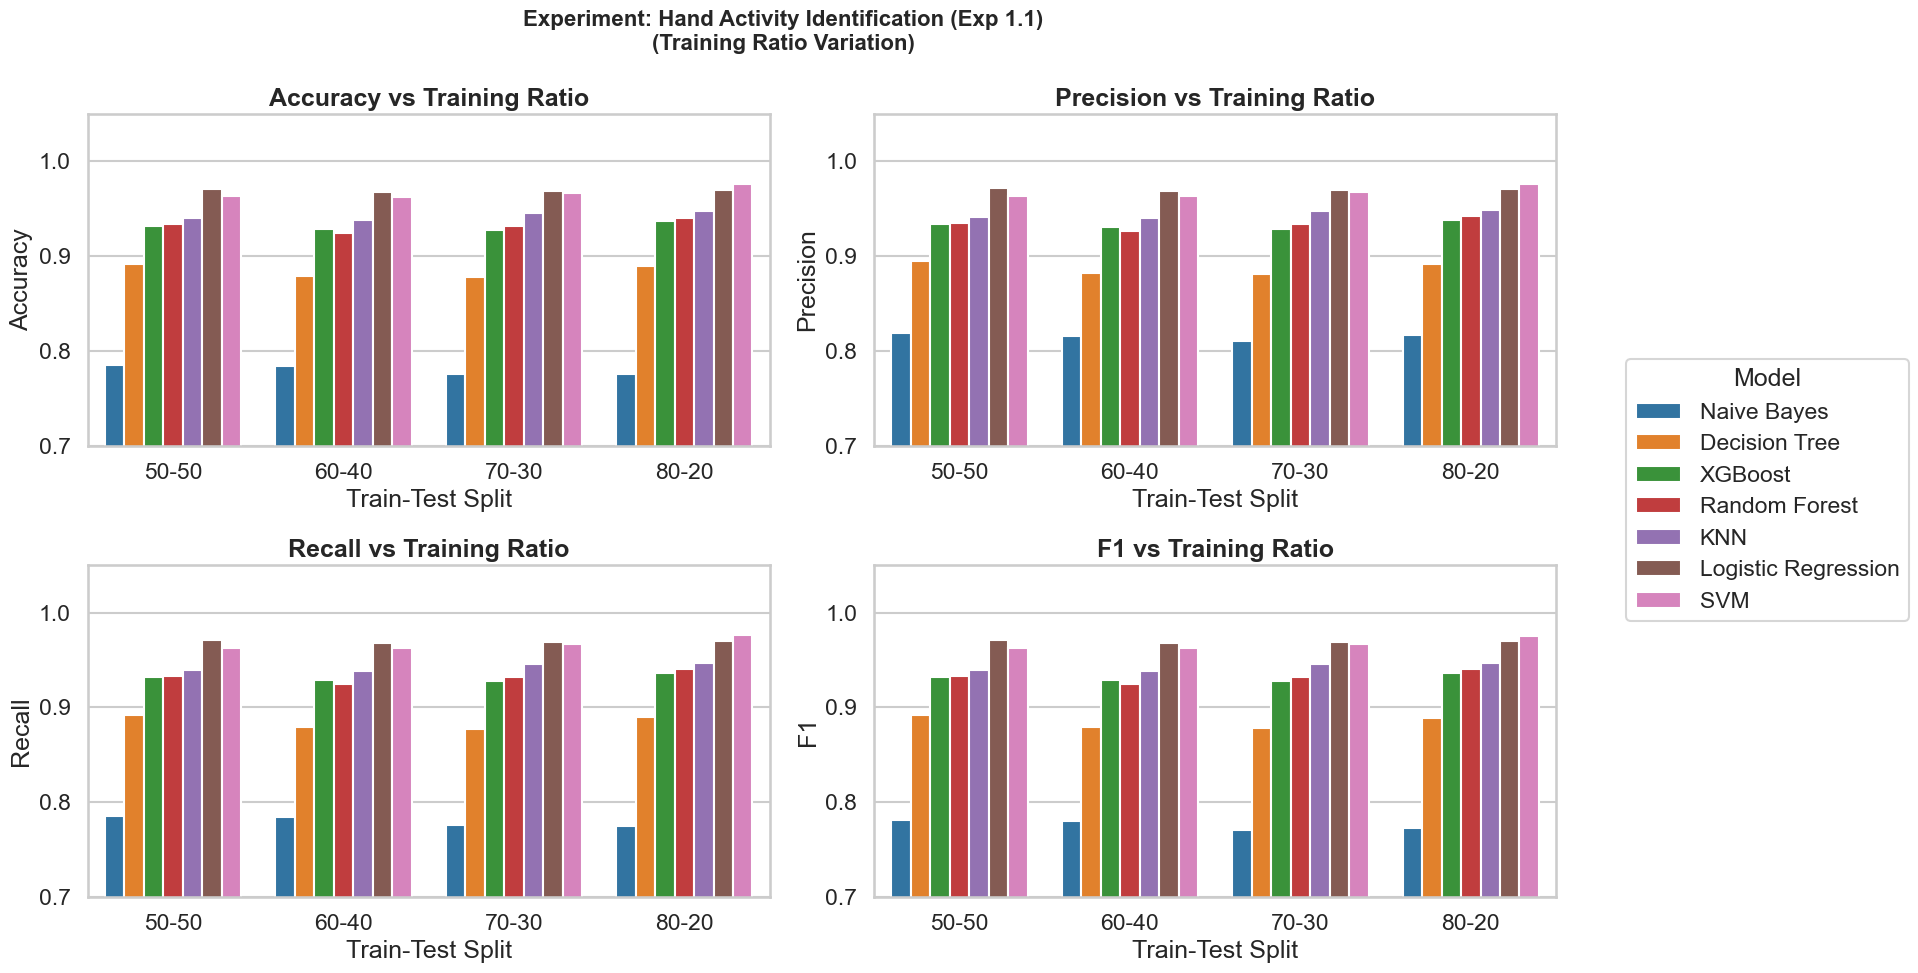

Saved: Exp1_1_HandActivity_TrainingRatio.png


In [10]:
plot_experiment_results(
    df_1_1.groupby(["Split", "Model"], as_index=False).mean(),
    "Hand Activity Identification (Exp 1.1)", "Training Ratio", "Split",
    "Train-Test Split", "Exp1_1_HandActivity_TrainingRatio.png")


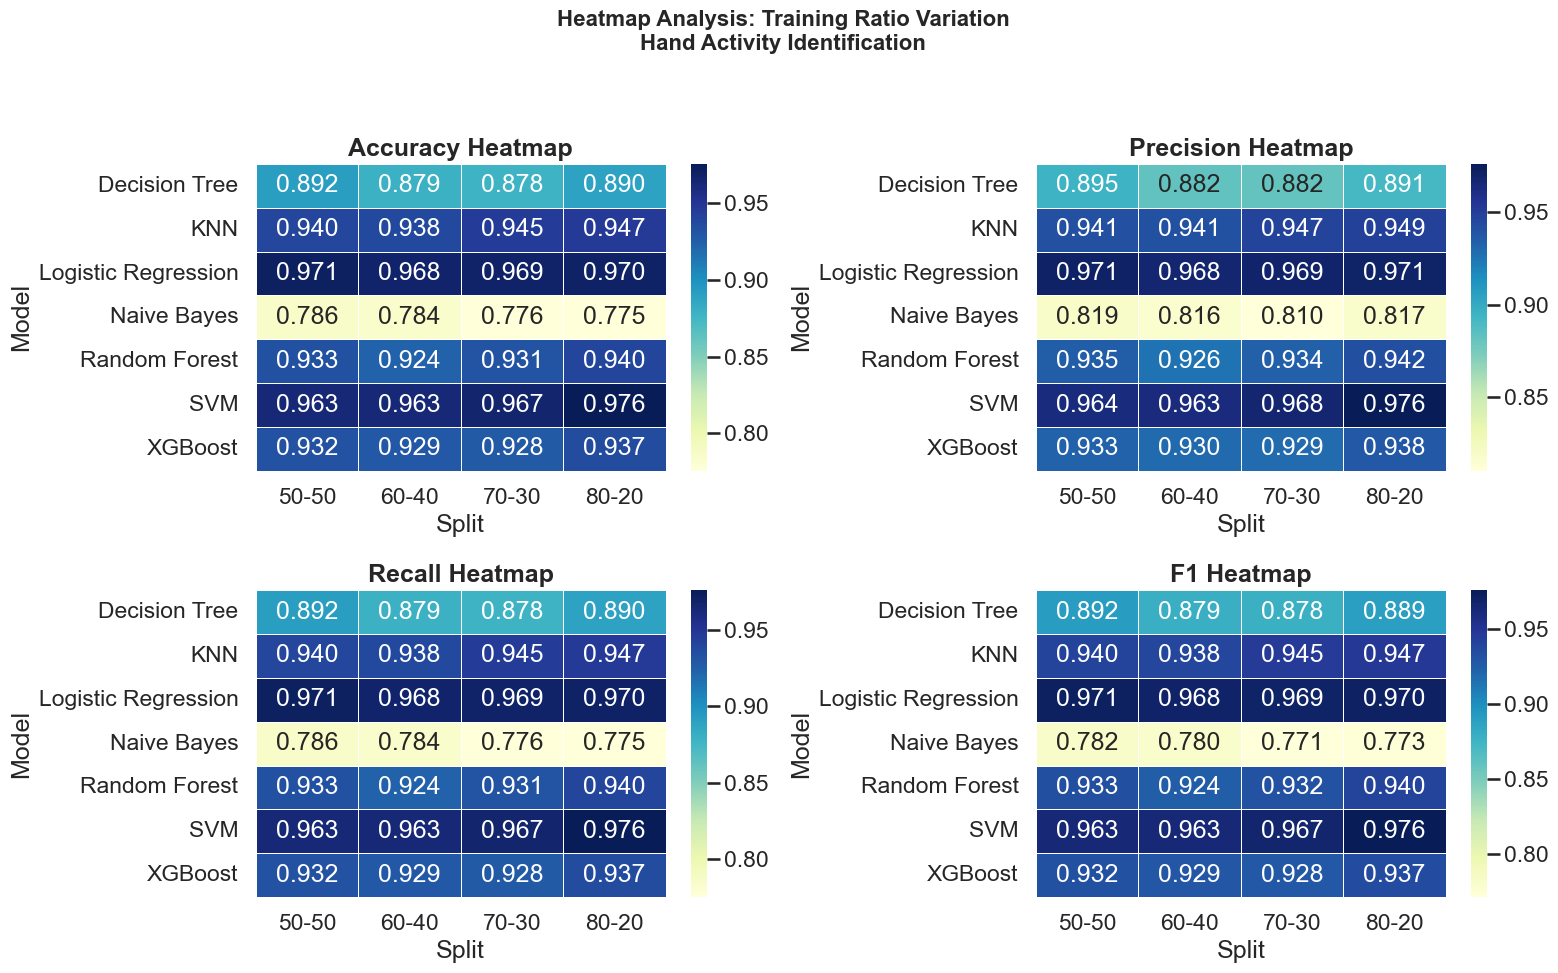

Saved: Exp1_1_Heatmap_HandActivity.png


In [11]:
plot_heatmaps(df_1_1, "Training Ratio", "Split", "Exp1_1_Heatmap_HandActivity.png",
              "Hand Activity Identification")


In [12]:
print_summary_stats(df_1_1, "Split", "Exp 1.1 - Training Ratio Variation")


SUMMARY STATISTICS - Exp 1.1 - Training Ratio Variation
                           Mean_Accuracy  Std_Accuracy  Mean_Precision  Mean_Recall  Mean_F1
Model               Split                                                                   
Decision Tree       50-50         0.8916        0.0104          0.8949       0.8916   0.8915
                    60-40         0.8788        0.0198          0.8824       0.8788   0.8789
                    70-30         0.8777        0.0209          0.8816       0.8777   0.8778
                    80-20         0.8895        0.0287          0.8914       0.8895   0.8893
KNN                 50-50         0.9397        0.0141          0.9414       0.9397   0.9399
                    60-40         0.9381        0.0133          0.9407       0.9381   0.9384
                    70-30         0.9453        0.0172          0.9473       0.9453   0.9454
                    80-20         0.9471        0.0276          0.9489       0.9471   0.9472
Logistic Regre

## 1.2 Variation of Data Size (Fixed Training Ratio = 80-20)

In [13]:
data_sizes = [0.4, 0.6, 0.8, 1.0]
results_1_2 = []

for size in data_sizes:
    size_pct = int(size * 100)
    print(f"\n{'='*50}")
    print(f"Processing Data Size: {size_pct}%")
    print(f"{'='*50}")
    
    df_sample = df.groupby("gesture_label", group_keys=False).apply(
        lambda x: x.sample(frac=size, random_state=42))
    
    X_ds = df_sample[dist_cols].values
    y_ds = df_sample['gesture_label'].values
    groups_ds = df_sample['person_id'].values
    
    gss = GroupShuffleSplit(n_splits=5, train_size=0.8, random_state=42)
    fold = 0
    for train_idx, test_idx in gss.split(X_ds, y_ds, groups_ds):
        fold += 1
        fold_start = time.time()
        X_train, X_test = X_ds[train_idx], X_ds[test_idx]
        y_train, y_test = y_ds[train_idx], y_ds[test_idx]
        
        std_scaler = StandardScaler().fit(X_train)
        mm_scaler = MinMaxScaler().fit(X_train)
        
        for name in model_names:
            try:
                model = get_model(name)
                metrics = scale_and_predict(model, X_train, X_test, y_train, y_test, name)
                results_1_2.append([f"{size_pct}%", name] + metrics)
            except Exception as e:
                print(f"  WARNING: {name} failed: {e}")
                results_1_2.append([f"{size_pct}%", name, 0.0, 0.0, 0.0, 0.0])
        
        elapsed = time.time() - fold_start
        print(f"  Fold {fold} completed in {elapsed:.1f}s")

df_1_2 = pd.DataFrame(results_1_2, columns=["Data_Size", "Model", "Accuracy", "Precision", "Recall", "F1"])
print("\nExperiment 1.2 Complete!")



Processing Data Size: 40%


  Fold 1 completed in 5.3s


  Fold 2 completed in 5.3s


  Fold 3 completed in 5.4s


  Fold 4 completed in 4.9s


...

  Fold 1 completed in 9.4s


  Fold 2 completed in 8.6s


  Fold 3 completed in 9.4s


  Fold 4 completed in 8.4s


  Fold 5 completed in 9.0s

Experiment 1.2 Complete!


In [14]:
final_1_2 = df_1_2.groupby(["Data_Size", "Model"], as_index=False).mean().round(4)
print(final_1_2.to_string())


   Data_Size                Model  Accuracy  Precision  Recall      F1
0       100%        Decision Tree    0.8895     0.8914  0.8895  0.8893
1       100%                  KNN    0.9471     0.9489  0.9471  0.9472
2       100%  Logistic Regression    0.9706     0.9712  0.9706  0.9706
3       100%          Naive Bayes    0.7754     0.8168  0.7754  0.7733
4       100%        Random Forest    0.9372     0.9388  0.9372  0.9373
5       100%                  SVM    0.9758     0.9763  0.9758  0.9757
6       100%              XGBoost    0.9366     0.9379  0.9366  0.9365
7        40%        Decision Tree    0.8817     0.8864  0.8817  0.8811
8        40%                  KNN    0.9354     0.9392  0.9354  0.9356
9        40%  Logistic Regression    0.9732     0.9737  0.9732  0.9732
10       40%          Naive Bayes    0.7706     0.8076  0.7706  0.7662
11       40%        Random Forest    0.9300     0.9323  0.9300  0.9300
12       40%                  SVM    0.9713     0.9718  0.9713  0.9712
13    

In [15]:
df_1_2.to_csv("Experiment1_HandActivity_DataSize.csv", index=False)
print("Saved: Experiment1_HandActivity_DataSize.csv")


Saved: Experiment1_HandActivity_DataSize.csv


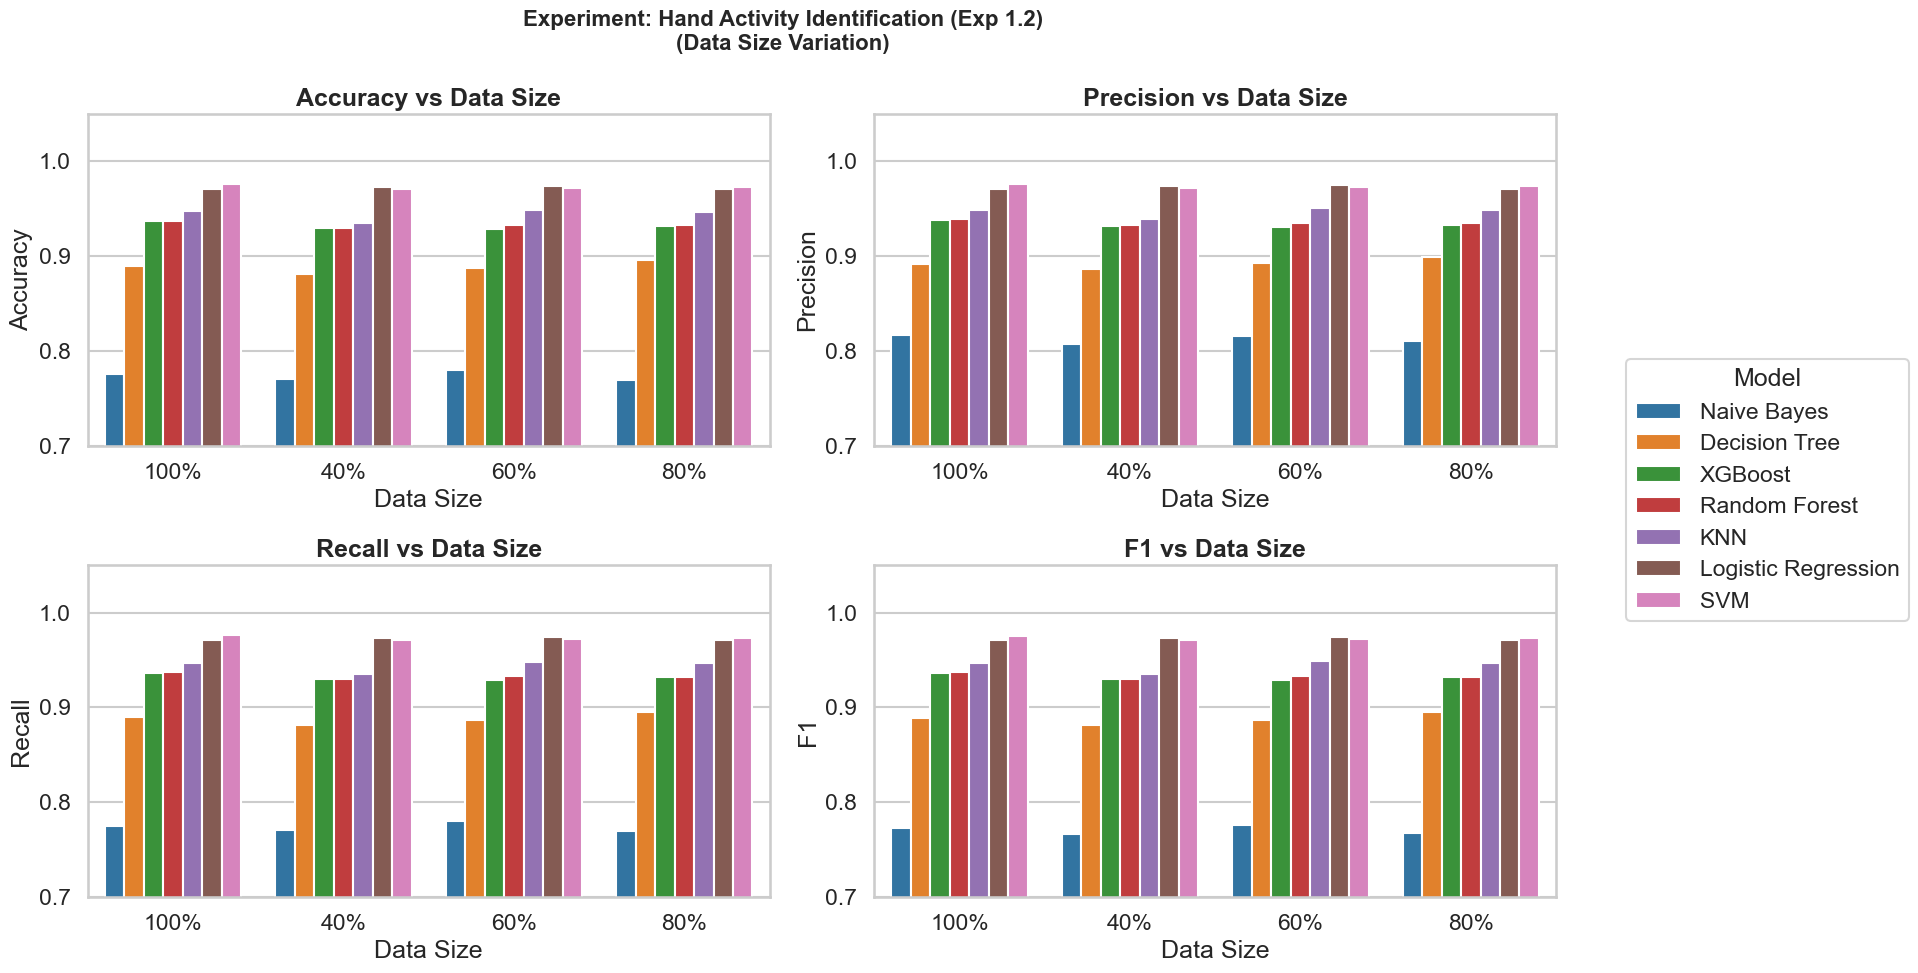

Saved: Exp1_2_HandActivity_DataSize.png


In [16]:
plot_experiment_results(
    df_1_2.groupby(["Data_Size", "Model"], as_index=False).mean(),
    "Hand Activity Identification (Exp 1.2)", "Data Size", "Data_Size",
    "Data Size", "Exp1_2_HandActivity_DataSize.png")


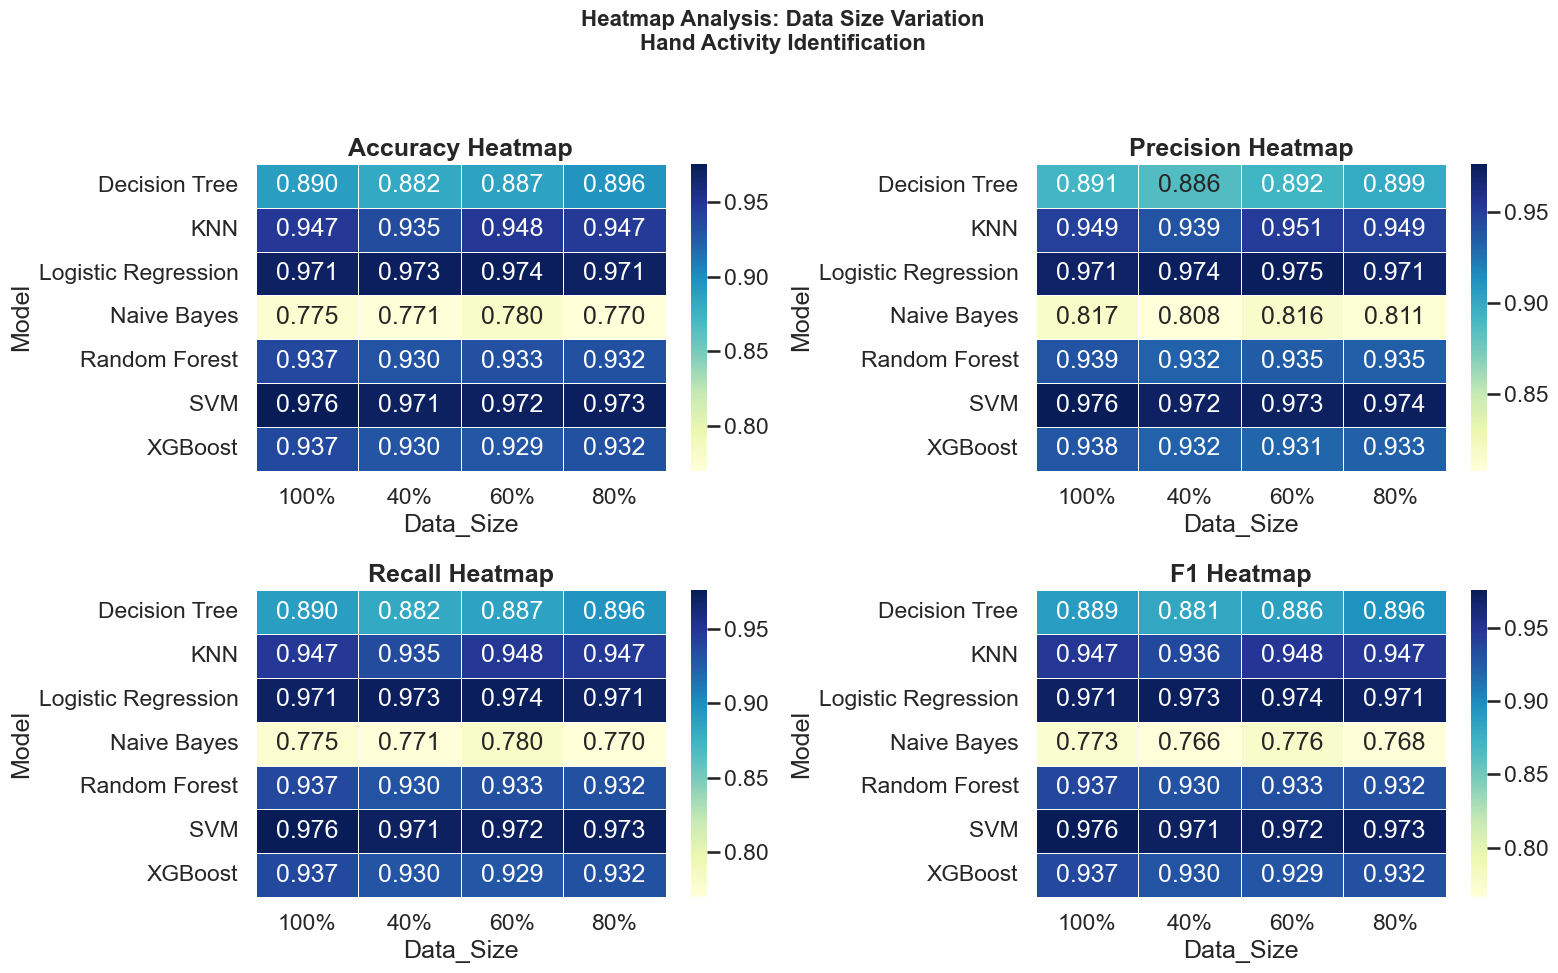

Saved: Exp1_2_Heatmap_HandActivity.png


In [17]:
plot_heatmaps(df_1_2, "Data Size", "Data_Size", "Exp1_2_Heatmap_HandActivity.png",
              "Hand Activity Identification")


In [18]:
print_summary_stats(df_1_2, "Data_Size", "Exp 1.2 - Data Size Variation")


SUMMARY STATISTICS - Exp 1.2 - Data Size Variation
                               Mean_Accuracy  Std_Accuracy  Mean_Precision  Mean_Recall  Mean_F1
Model               Data_Size                                                                   
Decision Tree       100%              0.8895        0.0287          0.8914       0.8895   0.8893
                    40%               0.8817        0.0467          0.8864       0.8817   0.8811
                    60%               0.8871        0.0359          0.8923       0.8871   0.8865
                    80%               0.8956        0.0474          0.8991       0.8956   0.8956
KNN                 100%              0.9471        0.0276          0.9489       0.9471   0.9472
                    40%               0.9354        0.0253          0.9392       0.9354   0.9356
                    60%               0.9482        0.0248          0.9510       0.9482   0.9485
                    80%               0.9466        0.0269          0.9489  

## Overall Comparison

In [19]:
print("=" * 80)
print("OVERALL BEST ACCURACY - HAND ACTIVITY IDENTIFICATION")
print("=" * 80)
print("\n--- Best Accuracy (Training Ratio Variation) ---")
best_1_1 = df_1_1.groupby("Model")["Accuracy"].max().sort_values(ascending=False)
for model, acc in best_1_1.items():
    print(f"  {model:25s}: {acc:.4f}")

print("\n--- Best Accuracy (Data Size Variation) ---")
best_1_2 = df_1_2.groupby("Model")["Accuracy"].max().sort_values(ascending=False)
for model, acc in best_1_2.items():
    print(f"  {model:25s}: {acc:.4f}")

print("\n--- Overall Best Model ---")
all_best = pd.concat([
    df_1_1.groupby("Model")["Accuracy"].max(),
    df_1_2.groupby("Model")["Accuracy"].max()
]).groupby(level=0).max().sort_values(ascending=False)
print(f"  {all_best.index[0]:25s}: {all_best.iloc[0]:.4f}")


OVERALL BEST ACCURACY - HAND ACTIVITY IDENTIFICATION

--- Best Accuracy (Training Ratio Variation) ---
  SVM                      : 0.9972
  Logistic Regression      : 0.9953
  Random Forest            : 0.9878
  XGBoost                  : 0.9803
  KNN                      : 0.9766
  Decision Tree            : 0.9353
  Naive Bayes              : 0.8538

--- Best Accuracy (Data Size Variation) ---
  SVM                      : 0.9972
  Logistic Regression      : 0.9969
  Random Forest            : 0.9878
  XGBoost                  : 0.9812
  KNN                      : 0.9771
  Decision Tree            : 0.9600
  Naive Bayes              : 0.8622

--- Overall Best Model ---
  SVM                      : 0.9972
